Podešavanja

In [1]:
DATA_DIR = r"raw-img"
SEED = 42
MAX_PER_CLASS = 1400
EPOCHS = 5
N_FOLDS = 5

In [2]:
import os
import sys
from PIL import Image
import warnings
import torch
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from torchvision import transforms
from pathlib import Path
import torch.nn as nn
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, OneCycleLR
from sklearn.metrics import (
    f1_score,confusion_matrix, classification_report,
    roc_auc_score,precision_recall_curve,roc_curve, average_precision_score,auc
)
from sklearn.model_selection import StratifiedKFold
import time
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import label_binarize
import pandas as pd


sys.path.insert(0, str('src'))
from dataset import (
    Animals10Dataset,
    CLASSES, NUM_CLASSES, IMG_SIZE,
)

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
PAL = sns.color_palette('tab10', n_colors=10)

DEVICE = torch.device('cpu')

print(f'PyTorch   : {torch.__version__}')
print(f'MLflow    : {mlflow.__version__}')
print(f'Uredjaj   : {DEVICE}')
print(f'Klase     : {CLASSES}')

PyTorch   : 2.12.0+cpu
MLflow    : 3.13.0
Uredjaj   : cpu
Klase     : ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


Fiksiranje sidova

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Seed fiksiran: {seed}")

seed_everything(SEED)

Seed fiksiran: 42


Mapa klasa i transformacije

In [4]:
NORMALIZE = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225],
)

def get_transform(split='train', strong=False):
    if split == 'train' and not strong:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    elif split == 'train' and strong:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.2),
            transforms.RandomGrayscale(p=0.05),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            NORMALIZE,
        ])

print('Transformacije definisane!')
print(f'IMG_SIZE  = {IMG_SIZE}px')
print(f'Normalizacija: mean={[0.485, 0.456, 0.406]}  std={[0.229, 0.224, 0.225]}')

Transformacije definisane!
IMG_SIZE  = 128px
Normalizacija: mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


Učitavanje dataseta

In [5]:
Path('results').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)


full_ds = Animals10Dataset(
    root_dir=DATA_DIR,
    transform=None,
    max_per_class=MAX_PER_CLASS,
)

if len(full_ds) == 0:
    print('\n!!! GRESKA: Nisu pronadjene slike!')
   
else:
    all_labels = full_ds.get_labels()
    counts     = full_ds.class_counts()
    print(f'Klase i broj slika:')
    for cls, cnt in counts.items():
        print(f'  {cls:<12}: {cnt}')

Dataset ucitan: 14000 slika, 10 klasa
Klase i broj slika:
  butterfly   : 1400
  cat         : 1400
  chicken     : 1400
  cow         : 1400
  dog         : 1400
  elephant    : 1400
  horse       : 1400
  sheep       : 1400
  spider      : 1400
  squirrel    : 1400


Definisanje CNN arhitektura

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

class MediumCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        def blok(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                )
        self.net = nn.Sequential(
            blok(3, 32), blok(32, 64), blok(64, 128), blok(128, 256),
            nn.AdaptiveAvgPool2d((3, 3)),
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(256*3*3, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes),
            )   
    def forward(self, x): return self.net(x)

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        cfg    = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M']
        layers = []
        ic = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(2))
            else:
                layers += [nn.Conv2d(ic, v, 3, padding=1), nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                ic = v
        self.features    = nn.Sequential(*layers)
        self.gap         = nn.AdaptiveAvgPool2d(1)
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.gap(self.features(x)))    

class TransferMobileNet(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
        backbone        = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(1280, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout/2), nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.pool(self.features(x)))

class ResNetCustom(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        from torchvision.models import resnet18, ResNet18_Weights
        backbone    = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_feats    = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(in_feats, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self.model = backbone
    def forward(self, x): return self.model(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_mb(model):
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
        path = f.name
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / (1024**2)
    os.unlink(path)
    return round(size, 2)


modeli_info = {
    'SimpleCNN':         SimpleCNN(NUM_CLASSES),
    'MediumCNN':         MediumCNN(NUM_CLASSES),
    'DeepCNN':           DeepCNN(NUM_CLASSES),
    'TransferMobileNet': TransferMobileNet(NUM_CLASSES),
    'ResNetCustom':      ResNetCustom(NUM_CLASSES),
}

print(f"{'Model':<22} {'Parametri':>12} {'Veličina':>10}")
print('-' * 48)
for name, m in modeli_info.items():
    print(f"{name:<22} {count_params(m):>12,} {model_mb(m):>9.2f} MB")

Model                     Parametri   Veličina
------------------------------------------------
SimpleCNN                   620,810      2.38 MB
MediumCNN                 2,359,466      9.03 MB
DeepCNN                   7,774,538     29.70 MB
TransferMobileNet         2,554,378      9.98 MB
ResNetCustom             11,310,410     43.22 MB


Petlje treniranja i evaluacija

In [7]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler=None, per_batch=False):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if per_batch and scheduler:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, 1)
        preds = probs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss/total, correct/total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def treniraj_fold(model, train_loader, val_loader, cfg, device, fold):
    epochs = cfg['epochs']

    
    params = [p for p in model.parameters() if p.requires_grad]
    if cfg['optimizer'] == 'adam':
        opt = Adam(params, lr=cfg['lr'], weight_decay=cfg.get('wd', 1e-4))
    elif cfg['optimizer'] == 'adamw':
        opt = AdamW(params, lr=cfg['lr'], weight_decay=cfg.get('wd', 1e-4))
    else:
        opt = SGD(params, lr=cfg['lr'], momentum=0.9, weight_decay=cfg.get('wd', 1e-4))

    
    per_batch = False
    if cfg['scheduler'] == 'cosine':
        sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    elif cfg['scheduler'] == 'step':
        sched = StepLR(opt, step_size=max(1, epochs//3), gamma=0.3)
    elif cfg['scheduler'] == 'onecycle':
        sched     = OneCycleLR(opt, max_lr=cfg['lr']*10,
                               steps_per_epoch=len(train_loader), epochs=epochs)
        per_batch = True
    else:
        sched = None

    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.get('ls', 0.0))
    model.to(device)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_acc, best_state = 0.0, None
    t_start = time.time()

    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device, sched, per_batch)
        vl, va, preds, labels, probs = eval_epoch(model, val_loader, criterion, device)
        if not per_batch and sched:
            sched.step()
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        print(f"    Epoha {ep:3d}/{epochs} | "
              f"tr_loss={tl:.4f} tr_acc={ta:.4f} | "
              f"val_loss={vl:.4f} val_acc={va:.4f}")

        mlflow.log_metrics({
            f'fold{fold}_train_loss': tl, f'fold{fold}_val_loss': vl,
            f'fold{fold}_train_acc':  ta, f'fold{fold}_val_acc':  va,
        }, step=ep)

        if va > best_acc:
            best_acc   = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    train_time = time.time() - t_start

    model.load_state_dict(best_state)
    model.to(device)
    _, fin_acc, fin_preds, fin_labels, fin_probs = eval_epoch(model, val_loader, criterion, device)

    model.eval()
    dummy = next(iter(val_loader))[0][:4].to(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(10): model(dummy)
    infer_ms = (time.perf_counter() - t0) / 10 / 4 * 1000

    try:
        auc_score = roc_auc_score(fin_labels, fin_probs, multi_class='ovr', average='macro')
    except:
        auc_score = float('nan')

    return {
        'fold': fold,
        'best_val_acc': best_acc,
        'f1':     f1_score(fin_labels, fin_preds, average='macro', zero_division=0),
        'auc':    auc_score,
        'report': classification_report(fin_labels, fin_preds, zero_division=0),
        'cm':     confusion_matrix(fin_labels, fin_preds),
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs':   train_accs,   'val_accs':   val_accs,
        'train_time_s': train_time,   'infer_ms':   infer_ms,
        'preds':  fin_preds,
        'labels': fin_labels,
        'probs':  fin_probs,
        'state':  best_state,
    }


print("Petlje treniranja definisane!")

Petlje treniranja definisane!


Konfiguracije i pokretanje eksperimenata

In [8]:
CONFIGS = [
    {
        'name':      'Config1_SimpleCNN_baseline',
        'model_cls': SimpleCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.3},
        'optimizer': 'adam',    'lr': 1e-3,
        'scheduler': 'cosine',  'wd': 1e-4,
        'ls': 0.0,  'strong_aug': False,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config2_MediumCNN_strongaug',
        'model_cls': MediumCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',   'lr': 5e-4,
        'scheduler': 'cosine',  'wd': 5e-4,
        'ls': 0.1,  'strong_aug': True,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config3_DeepCNN_sgd',
        'model_cls': DeepCNN,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.5},
        'optimizer': 'sgd',    'lr': 1e-2,
        'scheduler': 'step',   'wd': 5e-4,
        'ls': 0.0,  'strong_aug': False,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config4_MobileNet_finetune',
        'model_cls': TransferMobileNet,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',   'lr': 3e-4,
        'scheduler': 'cosine',  'wd': 1e-4,
        'ls': 0.1,  'strong_aug': True,
        'epochs': EPOCHS,
    },
    {
        'name':      'Config5_ResNet18_onecycle',
        'model_cls': ResNetCustom,
        'model_kw':  {'num_classes': NUM_CLASSES, 'dropout': 0.4},
        'optimizer': 'adamw',    'lr': 1e-3,
        'scheduler': 'onecycle', 'wd': 1e-4,
        'ls': 0.05, 'strong_aug': False,
        'epochs': EPOCHS,
    },
]

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_indices  = np.arange(len(full_ds))
all_summaries = []

mlflow.set_experiment('animals10_cnn')

for cfg in CONFIGS:
    print(f"\n{'='*65}")
    print(f"  {cfg['name']}")
    print(f"{'='*65}")

    fold_results = []

    with mlflow.start_run(run_name=cfg['name']):
        
        mlflow.log_params({
            'model':     cfg['model_cls'].__name__,
            'optimizer': cfg['optimizer'],
            'lr':        cfg['lr'],
            'scheduler': cfg['scheduler'],
            'epochs':    cfg['epochs'],
            'n_folds':   N_FOLDS,
            'strong_aug': cfg['strong_aug'],
            'label_smoothing': cfg['ls'],
            'seed':      SEED,
        })

        for fold, (train_idx, val_idx) in enumerate(
                skf.split(all_indices, all_labels), start=1):
            print(f"\n  -- Fold {fold}/{N_FOLDS}  "
                  f"(train={len(train_idx)}, val={len(val_idx)}) --")
            seed_everything(SEED + fold)

            tr_ds = Animals10Dataset(DATA_DIR,
                transform=get_transform('train', strong=cfg['strong_aug']),
                max_per_class=MAX_PER_CLASS)
            vl_ds = Animals10Dataset(DATA_DIR,
                transform=get_transform('val'),
                max_per_class=MAX_PER_CLASS)

            train_loader = DataLoader(Subset(tr_ds, train_idx),
                batch_size=32, shuffle=True,
                num_workers=0, pin_memory=False) 
            val_loader   = DataLoader(Subset(vl_ds, val_idx),
                batch_size=32, shuffle=False,
                num_workers=0, pin_memory=False)

            model  = cfg['model_cls'](**cfg['model_kw'])
            result = treniraj_fold(model, train_loader, val_loader,
                                   cfg, DEVICE, fold)
            fold_results.append(result)

            ckpt = f"models/{cfg['name']}_fold{fold}.pt"
            torch.save(result['state'], ckpt)

            mlflow.log_metrics({
                f'fold{fold}_best_acc': result['best_val_acc'],
                f'fold{fold}_f1':       result['f1'],
                f'fold{fold}_auc':      result['auc'],
            })

        accs = [r['best_val_acc'] for r in fold_results]
        f1s  = [r['f1']           for r in fold_results]
        mlflow.log_metrics({
            'mean_acc': np.mean(accs),
            'std_acc':  np.std(accs),
            'mean_f1':  np.mean(f1s),
        })

    
    cfg['_results'] = fold_results

    dummy = cfg['model_cls'](**cfg['model_kw'])
    all_summaries.append({
        'name':          cfg['name'],
        'model_size_mb': model_mb(dummy),
        'n_params':      count_params(dummy),
        'mean_acc':      float(np.mean(accs)),
        'std_acc':       float(np.std(accs)),
        'mean_f1':       float(np.mean(f1s)),
        'mean_auc':      float(np.nanmean([r['auc'] for r in fold_results])),
        'train_time_s':  float(np.sum([r['train_time_s'] for r in fold_results])),
        'mean_infer_ms': float(np.mean([r['infer_ms']    for r in fold_results])),
    })
    print(f"\n  >> Prosek: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  "
          f"F1={np.mean(f1s):.4f}")

print("\n\nSvi eksperimenti završeni!")


  Config1_SimpleCNN_baseline

  -- Fold 1/5  (train=11200, val=2800) --
Seed fiksiran: 43
Dataset ucitan: 14000 slika, 10 klasa
Dataset ucitan: 14000 slika, 10 klasa
    Epoha   1/5 | tr_loss=1.9958 tr_acc=0.2731 | val_loss=1.6991 val_acc=0.3907
    Epoha   2/5 | tr_loss=1.7511 tr_acc=0.3703 | val_loss=1.5751 val_acc=0.4371
    Epoha   3/5 | tr_loss=1.6164 tr_acc=0.4252 | val_loss=1.4869 val_acc=0.4679
    Epoha   4/5 | tr_loss=1.5303 tr_acc=0.4556 | val_loss=1.3344 val_acc=0.5257
    Epoha   5/5 | tr_loss=1.4586 tr_acc=0.4829 | val_loss=1.3039 val_acc=0.5475

  -- Fold 2/5  (train=11200, val=2800) --
Seed fiksiran: 44
Dataset ucitan: 14000 slika, 10 klasa
Dataset ucitan: 14000 slika, 10 klasa
    Epoha   1/5 | tr_loss=1.9863 tr_acc=0.2801 | val_loss=1.7217 val_acc=0.3914
    Epoha   2/5 | tr_loss=1.7272 tr_acc=0.3796 | val_loss=1.5643 val_acc=0.4536
    Epoha   3/5 | tr_loss=1.6215 tr_acc=0.4197 | val_loss=1.5000 val_acc=0.4668
    Epoha   4/5 | tr_loss=1.5327 tr_acc=0.4514 | val_los

Kriva učenja po modelu.

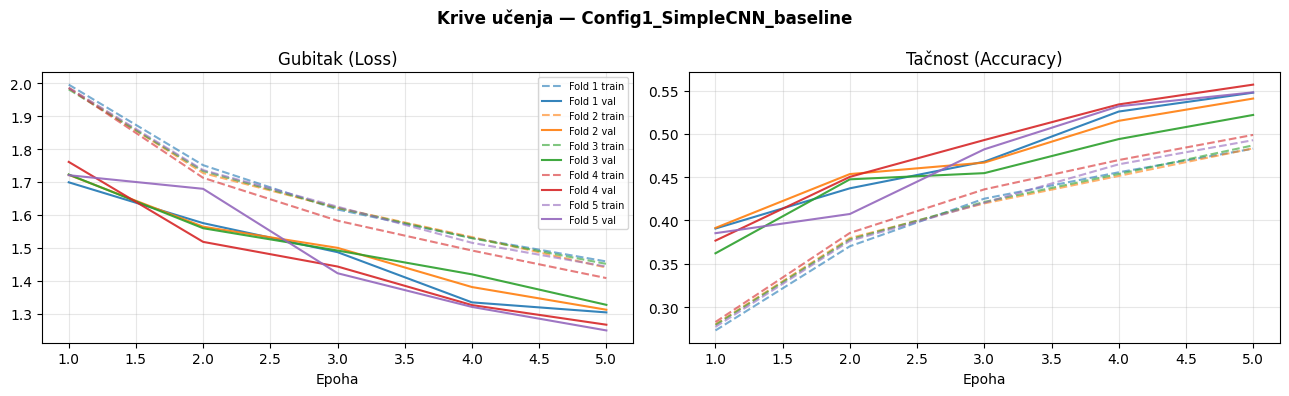

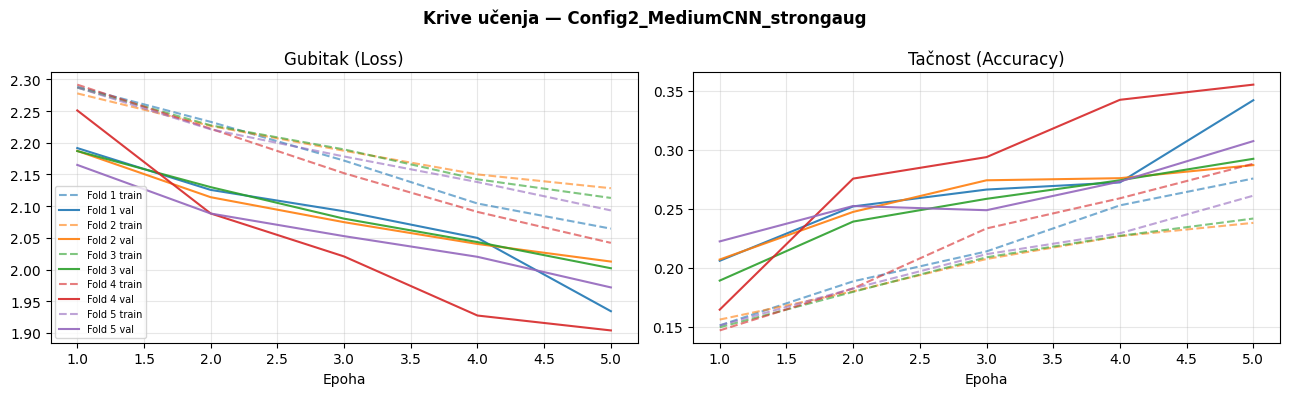

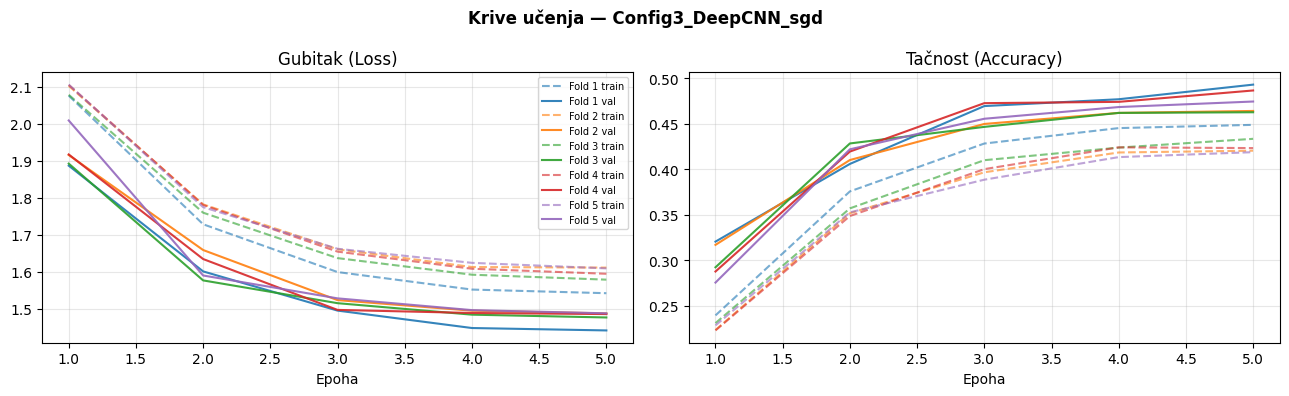

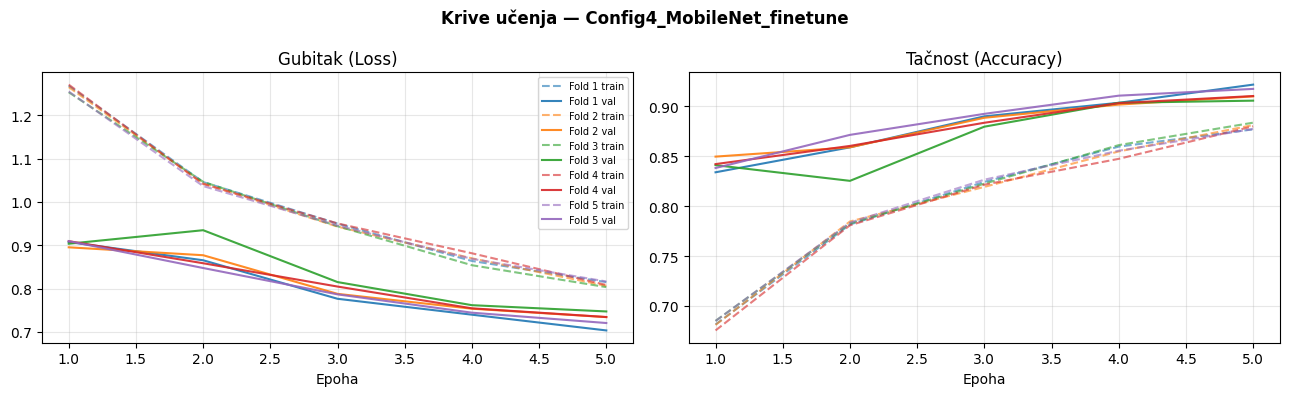

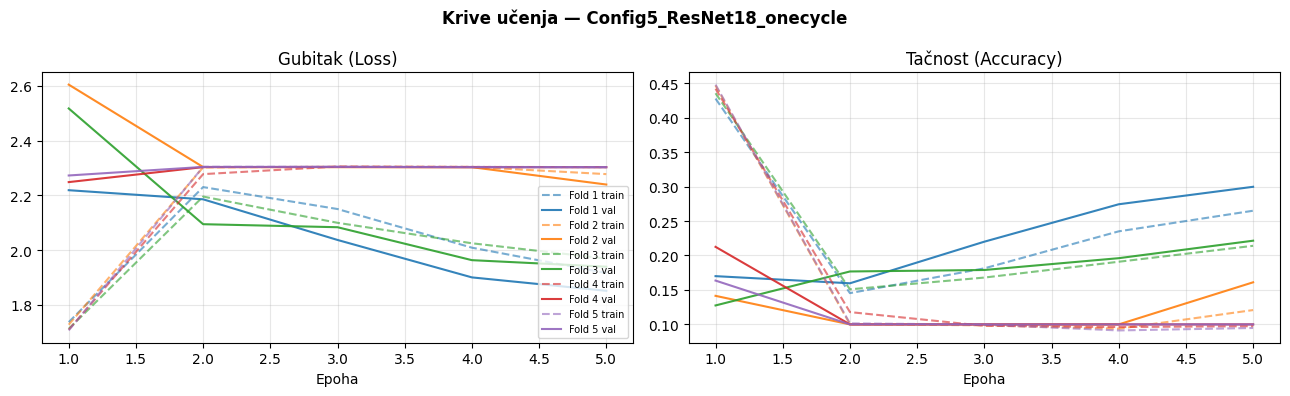

In [9]:
for cfg in CONFIGS:
    fold_results = cfg['_results']
    name         = cfg['name']
    Path(f'results/{name}').mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Krive učenja — {name}', fontsize=12, fontweight='bold')

    for i, res in enumerate(fold_results):
        ep = range(1, len(res['train_losses']) + 1)
        c  = PAL[i % NUM_CLASSES]
        axes[0].plot(ep, res['train_losses'], '--', color=c, alpha=0.6, label=f'Fold {i+1} train')
        axes[0].plot(ep, res['val_losses'],   '-',  color=c, alpha=0.9, label=f'Fold {i+1} val')
        axes[1].plot(ep, res['train_accs'],   '--', color=c, alpha=0.6)
        axes[1].plot(ep, res['val_accs'],     '-',  color=c, alpha=0.9)

    for ax, lbl in zip(axes, ['Gubitak (Loss)', 'Tačnost (Accuracy)']):
        ax.set_title(lbl); ax.set_xlabel('Epoha'); ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'results/{name}/learning_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

ROC i Precision-Recall krive

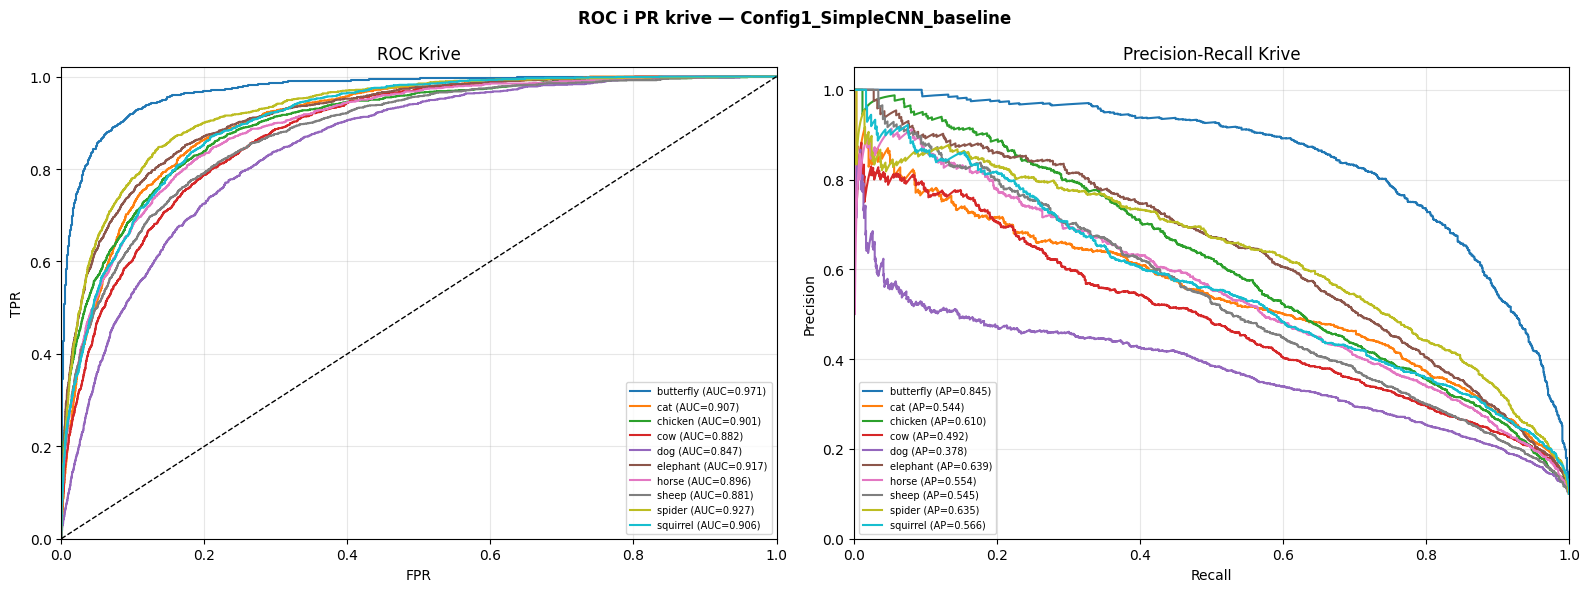

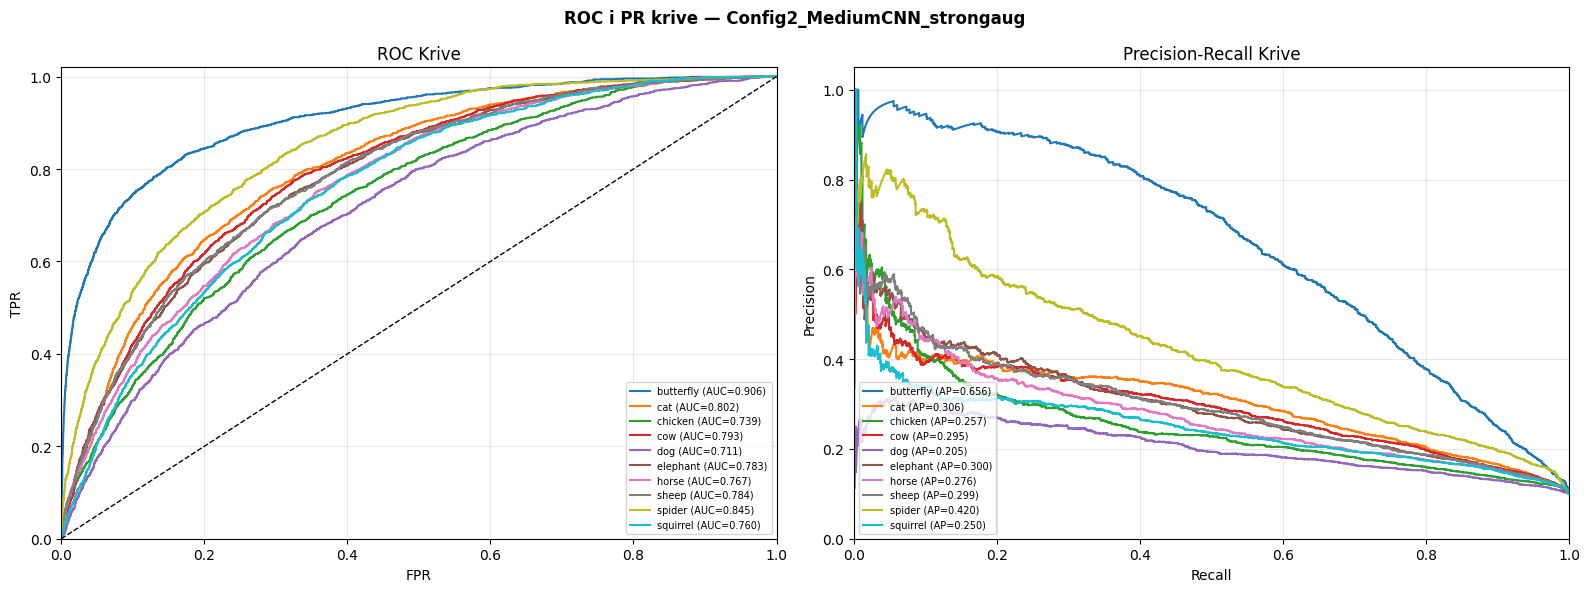

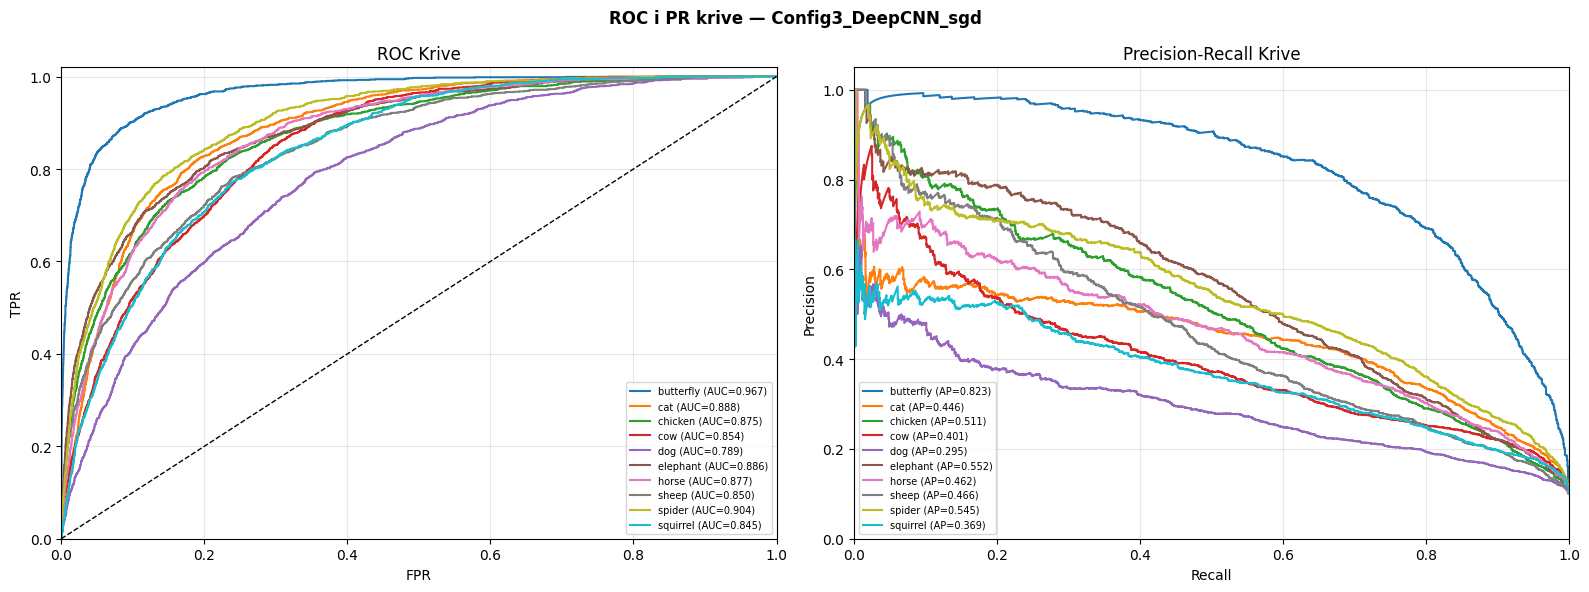

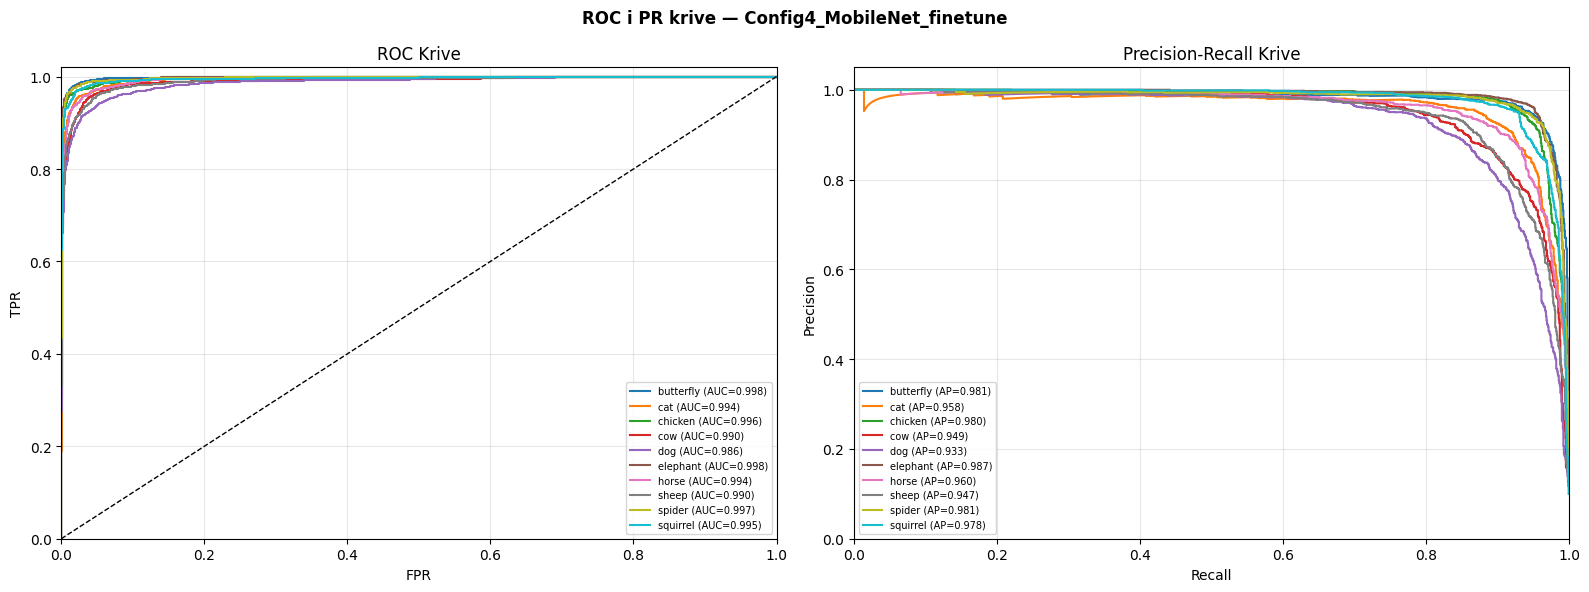

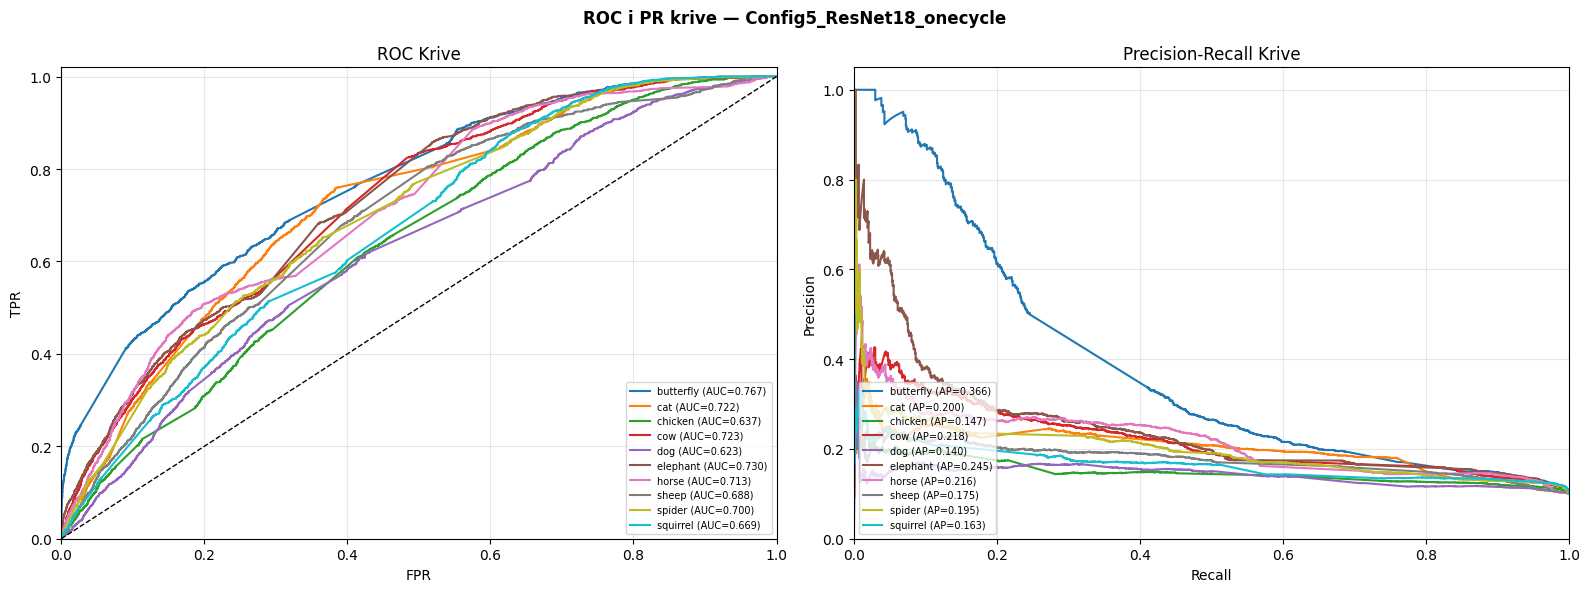

In [10]:
for cfg in CONFIGS:
    fold_results = cfg['_results']
    name         = cfg['name']

    all_true  = np.concatenate([r['labels'] for r in fold_results])
    all_probs = np.concatenate([r['probs']  for r in fold_results])
    lb        = label_binarize(all_true, classes=list(range(NUM_CLASSES)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'ROC i PR krive — {name}', fontsize=12, fontweight='bold')

    for i, cls in enumerate(CLASSES):
        c = PAL[i % NUM_CLASSES]
        # ROC
        fpr, tpr, _ = roc_curve(lb[:, i], all_probs[:, i])
        axes[0].plot(fpr, tpr, lw=1.5, color=c, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
        # PR
        prec, rec, _ = precision_recall_curve(lb[:, i], all_probs[:, i])
        ap = average_precision_score(lb[:, i], all_probs[:, i])
        axes[1].plot(rec, prec, lw=1.5, color=c, label=f'{cls} (AP={ap:.3f})')

    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set(xlim=[0,1], ylim=[0,1.02], xlabel='FPR', ylabel='TPR')
    axes[0].set_title('ROC Krive'); axes[0].legend(fontsize=7, loc='lower right')
    axes[0].grid(alpha=0.3)

    axes[1].set(xlim=[0,1], ylim=[0,1.05], xlabel='Recall', ylabel='Precision')
    axes[1].set_title('Precision-Recall Krive'); axes[1].legend(fontsize=7, loc='lower left')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'results/{name}/roc_pr_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

Tabela metrika po foldovima.

In [11]:
for cfg in CONFIGS:
    fold_results = cfg['_results']
    name         = cfg['name']
    print(f"\n{name}")
    print('-' * 70)

    df_fold = pd.DataFrame({
        'Fold':           [r['fold']                       for r in fold_results],
        'Val Acc':        [round(r['best_val_acc'], 4)     for r in fold_results],
        'F1 Macro':       [round(r['f1'], 4)               for r in fold_results],
        'AUC':            [round(r['auc'], 4)              for r in fold_results],
        'Trening (s)':    [round(r['train_time_s'], 1)     for r in fold_results],
        'Infer ms/slika': [round(r['infer_ms'], 3)         for r in fold_results],
    })

    prosek = df_fold.mean(numeric_only=True).round(4)
    prosek['Fold'] = 'Prosek'
    df_fold = pd.concat([df_fold, pd.DataFrame([prosek])], ignore_index=True)

    print(df_fold.to_string(index=False))
    df_fold.to_csv(f'results/{name}/fold_metrics.csv', index=False)

    
    print(f"\nClassification Report (poslednji fold):")
    print(fold_results[-1]['report'])


Config1_SimpleCNN_baseline
----------------------------------------------------------------------
  Fold  Val Acc  F1 Macro    AUC  Trening (s)  Infer ms/slika
     1   0.5475    0.5460 0.9021       607.70           1.922
     2   0.5407    0.5390 0.9003       597.40           1.951
     3   0.5218    0.5205 0.8986       595.10           1.943
     4   0.5568    0.5567 0.9069       597.80           1.962
     5   0.5479    0.5462 0.9112       598.60           1.957
Prosek   0.5429    0.5417 0.9038       599.32           1.947

Classification Report (poslednji fold):
              precision    recall  f1-score   support

           0       0.76      0.75      0.76       280
           1       0.53      0.58      0.56       280
           2       0.54      0.55      0.54       280
           3       0.46      0.49      0.47       280
           4       0.40      0.38      0.39       280
           5       0.54      0.68      0.61       280
           6       0.58      0.49      0.53    

Poređenje modela.

FINALNI REZULTATI svih modela
                       name  mean_acc  std_acc  mean_f1  mean_auc  model_size_mb  train_time_s  mean_infer_ms
 Config1_SimpleCNN_baseline  0.542929 0.011740 0.541668  0.903814           2.38   2996.689579       1.946934
Config2_MediumCNN_strongaug  0.316571 0.027149 0.278258  0.790973           9.03   7492.946800       5.631997
        Config3_DeepCNN_sgd  0.476357 0.012032 0.460930  0.873799          29.70  25676.131760      24.486104
 Config4_MobileNet_finetune  0.913071 0.005770 0.912837  0.993839           9.98   4636.988560       3.481237
  Config5_ResNet18_onecycle  0.211643 0.050416 0.133496  0.693813          43.22   4977.848663       5.084028


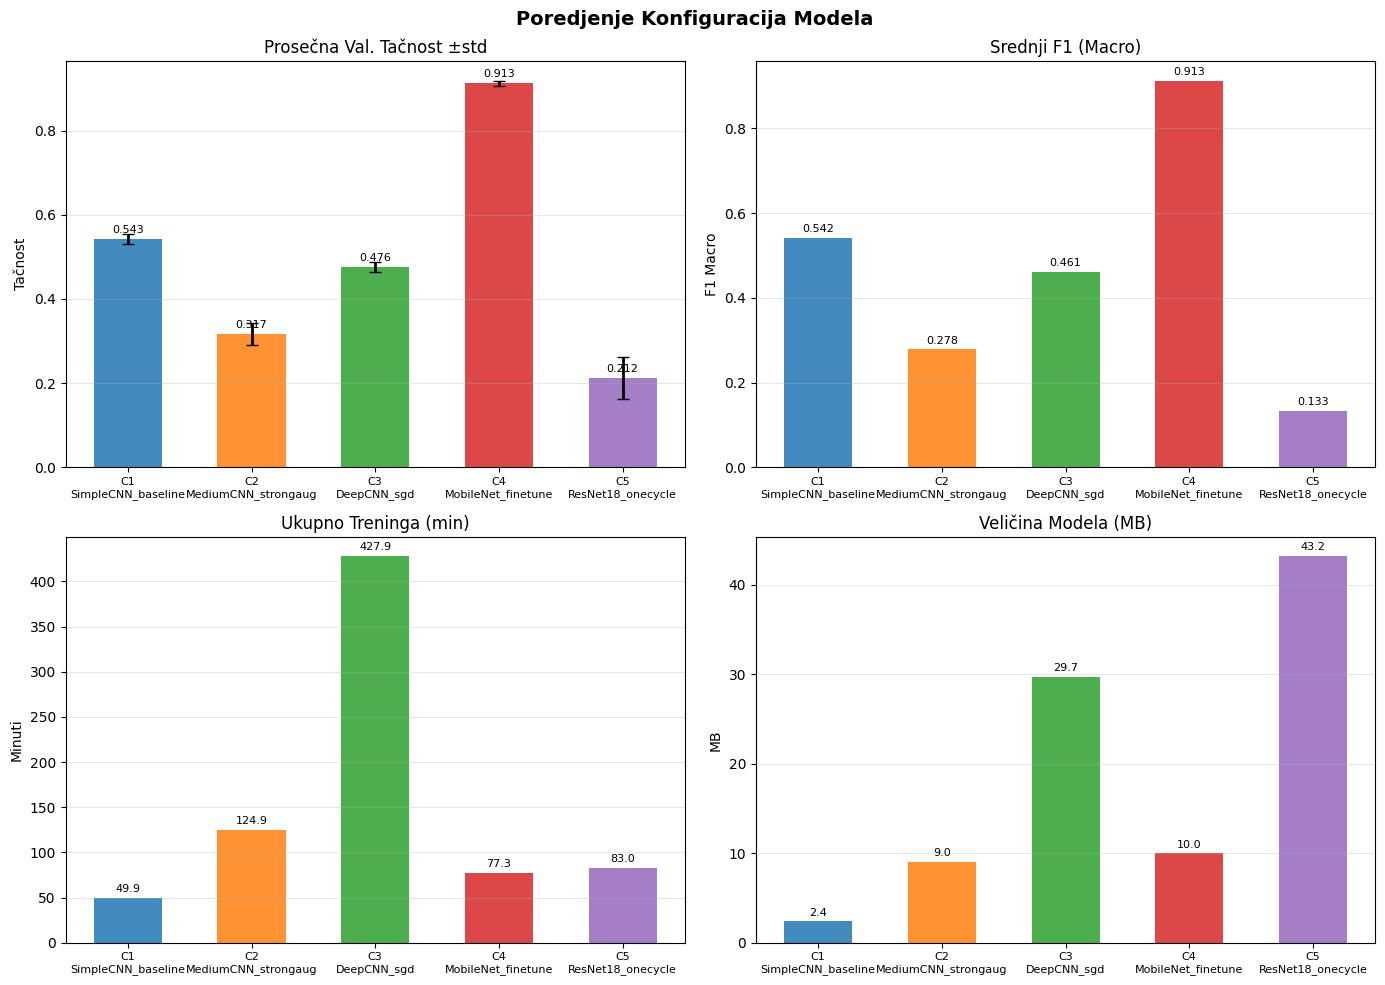


Najbolji model: Config4_MobileNet_finetune
  Acc  = 0.9131 ± 0.0058
  F1   = 0.9128
  AUC  = 0.9938


In [12]:
summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv('results/summary_table.csv', index=False)

print('FINALNI REZULTATI svih modela')
print('=' * 90)
cols = ['name','mean_acc','std_acc','mean_f1','mean_auc','model_size_mb','train_time_s','mean_infer_ms']
print(summary_df[cols].to_string(index=False))


names  = [r['name'].replace('Config', 'C').replace('_', '\n', 1) for r in all_summaries]
accs   = [r['mean_acc']        for r in all_summaries]
stds   = [r['std_acc']         for r in all_summaries]
f1s    = [r['mean_f1']         for r in all_summaries]
times  = [r['train_time_s']/60 for r in all_summaries]
sizes  = [r['model_size_mb']   for r in all_summaries]
x      = np.arange(len(names))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Poredjenje Konfiguracija Modela', fontsize=14, fontweight='bold')

def barchart(ax, vals, errs, ylabel, title, fmt='{:.3f}'):
    bars = ax.bar(x, vals, width=0.55, color=PAL[:len(names)], alpha=0.85,
                  yerr=errs, capsize=4 if errs else 0,
                  error_kw={'lw':2} if errs else {})
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=8)

barchart(axes[0,0], accs,  stds,  'Tačnost',  'Prosečna Val. Tačnost ±std')
barchart(axes[0,1], f1s,   None,  'F1 Macro', 'Srednji F1 (Macro)')
barchart(axes[1,0], times, None,  'Minuti',   'Ukupno Treninga (min)', fmt='{:.1f}')
barchart(axes[1,1], sizes, None,  'MB',       'Veličina Modela (MB)',  fmt='{:.1f}')

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best = max(all_summaries, key=lambda r: r['mean_acc'])
print(f"\nNajbolji model: {best['name']}")
print(f"  Acc  = {best['mean_acc']:.4f} ± {best['std_acc']:.4f}")
print(f"  F1   = {best['mean_f1']:.4f}")
print(f"  AUC  = {best['mean_auc']:.4f}")